In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
# import sk learn libraries
import sklearn.tree
import sklearn.linear_model
import sklearn.metrics
import sklearn.ensemble
from sklearn.model_selection import cross_val_score, KFold, GroupKFold, StratifiedGroupKFold
import cv2

In [2]:
img_file = "x_train_img.npz"
metadata_file = "x_train.csv"
y_file = "y_train.csv"

In [3]:
X_dev = pd.read_csv(metadata_file)
y_dev = pd.read_csv(y_file)
X_dev

,patient_id,img_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,fitspatrick,region,diameter_1,diameter_2,itch,grew,hurt,changed,bleed,elevation
0,PAT_620,PAT_620_001,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,3.0,NECK,6.0,5.0,True,True,False,True,True,True
1,PAT_388,PAT_388_002,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,1.0,FOREARM,5.0,5.0,True,True,False,False,True,True
2,PAT_518,PAT_518_003,False,True,GERMANY,ITALY,52,False,FEMALE,False,...,3.0,FACE,15.0,10.0,False,True,False,True,True,True
3,PAT_635,PAT_635_004,False,False,POMERANIA,POMERANIA,74,True,FEMALE,False,...,1.0,FACE,15.0,10.0,True,True,True,False,True,True
4,PAT_447,PAT_447_005,False,True,GERMANY,GERMANY,58,True,FEMALE,True,...,1.0,FOREARM,9.0,7.0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,PAT_409,PAT_409_1470,True,False,POMERANIA,POMERANIA,66,False,MALE,True,...,2.0,EAR,20.0,15.0,True,False,True,False,True,True
1174,PAT_640,PAT_640_1471,False,False,POMERANIA,POMERANIA,41,True,MALE,False,...,2.0,FACE,9.0,5.0,True,UNK,True,UNK,True,True
1175,PAT_539,PAT_539_1472,False,False,POMERANIA,POMERANIA,43,True,FEMALE,True,...,2.0,FACE,9.0,5.0,True,UNK,False,UNK,True,True
1176,PAT_620,PAT_620_1473,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,3.0,CHEST,13.0,12.0,True,True,False,True,False,False


In [4]:
y_dev.head()

,patient_id,img_id,coarse_label,fine_label
0,PAT_620,PAT_620_001,1,BCC
1,PAT_388,PAT_388_002,1,BCC
2,PAT_518,PAT_518_003,1,BCC
3,PAT_635,PAT_635_004,1,BCC
4,PAT_447,PAT_447_005,1,ACK


In [5]:
# Function and code to load images
def load_img_data(file_path):
    with np.load(file_path) as data:
        img = data['images']
        ids = data['image_ids']
    print(f"Successfully loaded {img.shape[0]} images.")  
    return img, ids

imgs, img_ids = load_img_data(img_file)
print(img_ids.shape, imgs.shape)

# Make sure the IDs match and are in the same order
assert np.all(img_ids == X_dev['img_id']), "Image IDs in metadata and image data do not match"

Successfully loaded 1178 images.
(1178,) (1178, 256, 256, 3)


<Axes: xlabel='count', ylabel='fine_label'>

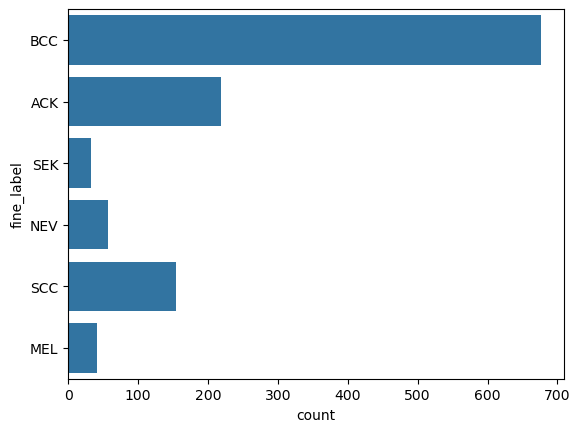

In [6]:
# Plot the class balance
sns.countplot(y_dev["fine_label"])

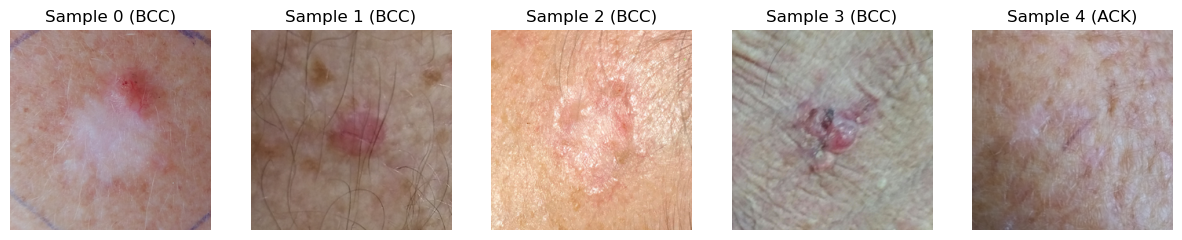

In [7]:
# Show the first 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    axes[i].imshow(imgs[i])
    axes[i].axis('off')
    axes[i].set_title(f"Sample {i} ({y_dev.iloc[i]["fine_label"]})")

plt.show()

In [8]:
# These are the 3 columns in X that have categorical data.
# Everything else is binary or numeric. 
categorical_cols = ['background_father', 'background_mother', 'region'] 

# Get all obvious true/false cols that aren't already true/false
for col in X_dev.select_dtypes(include=['object']):
    if X_dev[col].dropna().astype(str).str.contains('True|False').any():
        print(f"Automatically converting {col} to binary...")
        unmapped = X_dev[~X_dev[col].isin(['True','False'])][col].unique()
        print("The following values are being mapped to NaN in this column: ", unmapped)
        X_dev[col] = X_dev[col].map({'True': 1, 'False': 0, True: 1, False: 0})

X_dev['gender'] = X_dev['gender'].map({'MALE': 0, 'FEMALE': 1})

# Handle the categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_feats = encoder.fit_transform(X_dev[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_feats, 
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_dev.index
)

# Drop original text columns and join the new numeric ones
X_dev = X_dev.drop(columns=categorical_cols).join(encoded_df)

Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting elevation to binary...
The following values are being mapped to NaN in this column:  ['UNK']


In [9]:
age_groups = pd.cut(
    X_dev['age'], 
    bins=[0, 30, 60, 100], 
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

In [10]:
# First we'll calculate how much missing data there is
X_dev.isna().sum()

patient_id                         0
img_id                             0
smoke                              0
drink                              0
age                                0
pesticide                          0
gender                             0
skin_cancer_history                0
cancer_history                     0
has_piped_water                    0
has_sewage_system                  0
fitspatrick                        0
diameter_1                         0
diameter_2                         0
itch                               4
grew                             323
hurt                               8
changed                          319
bleed                              4
elevation                          2
background_father_AUSTRIA          0
background_father_BRASIL           0
background_father_BRAZIL           0
background_father_CZECH            0
background_father_GERMANY          0
background_father_ISRAEL           0
background_father_ITALY            0
b

In [11]:
# Then we'll decide what to do. For now we'll just treat missing data as false, 
# since it probably means that a patient didn't think the question was important or relevant.
X_dev = X_dev.fillna(0)
X_dev

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH
0,PAT_620,PAT_620_001,False,False,55,False,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,PAT_388,PAT_388_002,False,True,79,False,0,True,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PAT_518,PAT_518_003,False,True,52,False,1,False,True,True,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PAT_635,PAT_635_004,False,False,74,True,1,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PAT_447,PAT_447_005,False,True,58,True,1,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,PAT_409,PAT_409_1470,True,False,66,False,0,True,False,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1174,PAT_640,PAT_640_1471,False,False,41,True,0,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1175,PAT_539,PAT_539_1472,False,False,43,True,1,True,True,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1176,PAT_620,PAT_620_1473,False,False,55,False,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
def calculate_region_contrast(img_rgb):
    """
    Calculates the mean intensity difference between the lesion 
    and the surrounding skin.
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    kernel = np.ones((5, 5), np.uint8)
    dilated_mask = cv2.dilate(mask, kernel, iterations=4)
    outer_mask = cv2.subtract(dilated_mask, mask)

    inner_pixels = gray[mask > 0]
    outer_pixels = gray[outer_mask > 0]

    # Error Case
    if inner_pixels.size == 0 or outer_pixels.size == 0:
        return 0.0
    
    contrast = np.abs(np.mean(inner_pixels) - np.mean(outer_pixels))

    return contrast

In [13]:
# print out the column names
X_dev.columns

Index(['patient_id', 'img_id', 'smoke', 'drink', 'age', 'pesticide', 'gender',
       'skin_cancer_history', 'cancer_history', 'has_piped_water',
       'has_sewage_system', 'fitspatrick', 'diameter_1', 'diameter_2', 'itch',
       'grew', 'hurt', 'changed', 'bleed', 'elevation',
       'background_father_AUSTRIA', 'background_father_BRASIL',
       'background_father_BRAZIL', 'background_father_CZECH',
       'background_father_GERMANY', 'background_father_ISRAEL',
       'background_father_ITALY', 'background_father_NETHERLANDS',
       'background_father_POLAND', 'background_father_POMERANIA',
       'background_father_PORTUGAL', 'background_father_SPAIN',
       'background_father_UNK', 'background_mother_BRAZIL',
       'background_mother_GERMANY', 'background_mother_ITALY',
       'background_mother_NETHERLANDS', 'background_mother_NORWAY',
       'background_mother_POLAND', 'background_mother_POMERANIA',
       'background_mother_PORTUGAL', 'background_mother_SPAIN',
       'bac

In [14]:
# Add image contrast as a feature to the dataset
image_contrast_values = [calculate_region_contrast(img) for img in imgs]
X_dev['img_contrast'] = image_contrast_values

In [15]:
# Add color variation feature

color_N_3 = np.std(imgs, axis=(1, 2))
R = color_N_3[:, 0]
G = color_N_3[:, 1]
B = color_N_3[:, 2]

X_dev['red_variation'] = R
X_dev['green_variation'] = G
X_dev['blue_variation'] = B

In [16]:
X_dev.head()

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH,img_contrast,red_variation,green_variation,blue_variation
0,PAT_620,PAT_620_001,False,False,55,False,1,True,True,True,...,0.0,0.0,1.0,0.0,0.0,0.0,24.924036,13.827750,21.668840,25.263227
1,PAT_388,PAT_388_002,False,True,79,False,0,True,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,22.834889,14.268699,18.281030,18.465258
2,PAT_518,PAT_518_003,False,True,52,False,1,False,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,23.367400,12.082949,18.590016,22.089448
3,PAT_635,PAT_635_004,False,False,74,True,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,23.331572,11.291585,16.961407,14.955407
4,PAT_447,PAT_447_005,False,True,58,True,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,35.077083,22.398916,25.774490,31.113438


In [17]:
# create a list of features to use
feature_list = ['smoke', 'drink', 'age', 'pesticide',
                'gender', 'skin_cancer_history', 'cancer_history'
                ,'has_piped_water', 'has_sewage_system', 'fitspatrick',


                'region_HAND', 'region_LIP', 'region_NECK', 'region_NOSE', 'region_SCALP',
                'region_THIGH', 'region_ABDOMEN', 'region_ARM', 'region_BACK', 'region_EAR',
                'region_FACE', 'region_FOOT', 'region_FOREARM', 'region_CHEST',


                'diameter_1', 'diameter_2', 'itch', 'grew',
                'hurt', 'changed', 'bleed', 'elevation', 'img_contrast',
                'red_variation', 'green_variation', 'blue_variation']

In [18]:
# Base Forest
base_forest = sklearn.ensemble.RandomForestClassifier(class_weight = 'balanced', criterion='entropy')

In [19]:
# Hyperparameter Grid
forest_hyperparameter_grid = dict(
    max_features=[2, 3, 5, 10],
    max_depth=[2,4,8,16,32, 64],
    min_samples_leaf=[5,10],
    n_estimators=[100,500,1000]
    )

In [20]:
# Set up the cross validation
kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups = X_dev['patient_id']

In [21]:
# Set up the actual model selection using gridsearch
forest_searcher = sklearn.model_selection.GridSearchCV(
    estimator = base_forest,
    param_grid = forest_hyperparameter_grid,
    scoring = 'roc_auc',
    cv = kf,
    return_train_score = True,
    refit = True,
    n_jobs = -1)

In [22]:
# Create the datasers to fit
x_train = X_dev[feature_list]
y_train = y_dev['coarse_label']

In [23]:
# Fit the model
forest_searcher.fit(x_train,y_train, groups = groups)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ion='entropy')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'max_features': [2, 3, ...], 'min_samples_leaf': [5, 10], 'n_estimators': [100, 500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

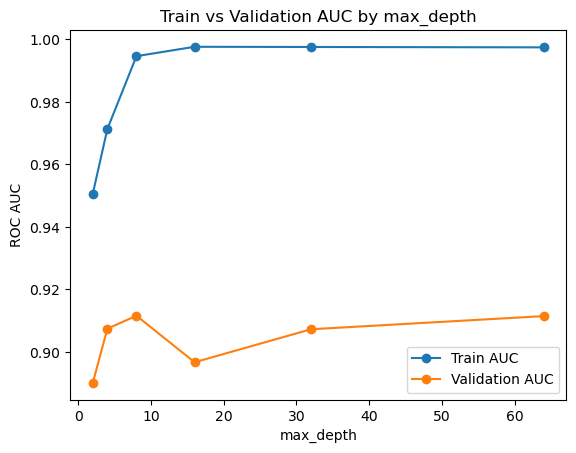

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(forest_searcher.cv_results_)

# Filter to a fixed set of other params to isolate the effect of max_depth
filtered = results[
    (results['param_n_estimators'] == 100) &
    (results['param_min_samples_leaf'] == 5) &
    (results['param_max_features'] == 2)
]

# Group by max_depth and average scores
grouped = filtered.groupby('param_max_depth').agg(
    mean_train=('mean_train_score', 'mean'),
    mean_val=('mean_test_score', 'mean')
).reset_index()

plt.plot(grouped['param_max_depth'], grouped['mean_train'], label='Train AUC', marker='o')
plt.plot(grouped['param_max_depth'], grouped['mean_val'], label='Validation AUC', marker='o')
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Train vs Validation AUC by max_depth')
plt.legend()
plt.show()

In [25]:
# load the test data
x_test = pd.read_csv('x_test.csv')
img_file_test = 'x_test_img.npz'
test_imgs, test_img_ids = load_img_data(img_file_test)

Successfully loaded 296 images.


In [26]:
# make sure the image ids match
assert np.all(test_img_ids == x_test['img_id']), "Image IDs in metadata and image data do not match"

In [27]:
# Encode the test categorical data
# Everything else is binary or numeric. 
categorical_cols = ['background_father', 'background_mother', 'region'] 

# Get all obvious true/false cols that aren't already true/false
for col in x_test.select_dtypes(include=['object']):
    if x_test[col].dropna().astype(str).str.contains('True|False').any():
        print(f"Automatically converting {col} to binary...")
        unmapped = x_test[~x_test[col].isin(['True','False'])][col].unique()
        print("The following values are being mapped to NaN in this column: ", unmapped)
        x_test[col] = x_test[col].map({'True': 1, 'False': 0, True: 1, False: 0})

x_test['gender'] = x_test['gender'].map({'MALE': 0, 'FEMALE': 1})

# Handle the categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_feats = encoder.fit_transform(x_test[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_feats, 
    columns=encoder.get_feature_names_out(categorical_cols),
    index=x_test.index
)

# Drop original text columns and join the new numeric ones
x_test = x_test.drop(columns=categorical_cols).join(encoded_df)

Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['UNK']


In [28]:
# make age groups feature
age_groups = pd.cut(
    x_test['age'], 
    bins=[0, 30, 60, 100], 
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

In [29]:
# get rid of missing test data
x_test = x_test.fillna(0)
x_test

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH
0,PAT_667,PAT_667_275,False,False,71,False,0,True,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,PAT_736,PAT_736_156,False,False,51,True,0,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,PAT_628,PAT_628_085,True,False,58,True,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,PAT_461,PAT_461_083,False,False,80,False,0,False,True,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,PAT_059,PAT_059_262,False,False,38,False,0,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,PAT_307,PAT_307_189,False,False,75,False,1,True,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
292,PAT_321,PAT_321_072,False,False,71,False,1,False,True,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
293,PAT_152,PAT_152_107,False,False,67,True,0,False,True,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
294,PAT_526,PAT_526_271,False,False,62,True,1,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [30]:
# Add image contrast as a feature to the test dataset
image_contrast_values = [calculate_region_contrast(test_img) for test_img in test_imgs]
x_test['img_contrast'] = image_contrast_values

In [31]:
# Add color variation feature

color_test = np.std(test_imgs, axis=(1, 2))
R_test = color_test[:, 0]
G_test = color_test[:, 1]
B_test = color_test[:, 2]

x_test['red_variation'] = R_test
x_test['green_variation'] = G_test
x_test['blue_variation'] = B_test

In [32]:
#Get the correct columns
x_test_final = x_test[feature_list]

In [33]:
# get the final predictions
y_proba = forest_searcher.predict_proba(x_test_final)[:,1]
np.savetxt('yproba1_test.txt', y_proba)

In [34]:
print(y_dev["coarse_label"].sum())
print(len(y_dev["coarse_label"]))

1089
1178


In [35]:
importances = forest_searcher.best_estimator_.feature_importances_
feature_names = x_train.columns

# Put into a dataframe and sort
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df)

                feature  importance
26                 itch    0.129870
2                   age    0.103314
30                bleed    0.087257
25           diameter_2    0.060685
28                 hurt    0.059714
32         img_contrast    0.055539
35       blue_variation    0.055107
24           diameter_1    0.054857
33        red_variation    0.048872
34      green_variation    0.048152
9           fitspatrick    0.024527
3             pesticide    0.023446
13          region_NOSE    0.022481
18          region_BACK    0.022307
22       region_FOREARM    0.020193
0                 smoke    0.018003
31            elevation    0.015041
27                 grew    0.013169
20          region_FACE    0.013065
29              changed    0.012521
8     has_sewage_system    0.012142
6        cancer_history    0.011941
5   skin_cancer_history    0.011920
15         region_THIGH    0.011503
4                gender    0.011133
7       has_piped_water    0.011094
1                 drink    0

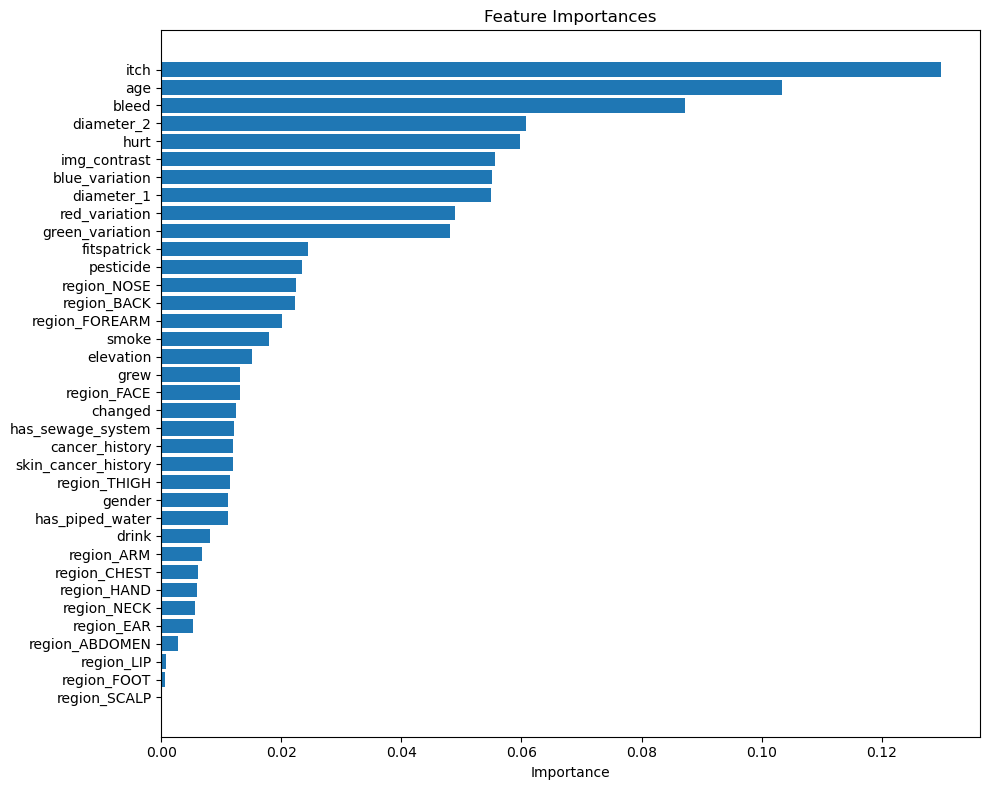

In [36]:
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # most important at top
plt.tight_layout()
plt.show()

In [37]:
def plot_hyperparam_curve(results, param_name, fixed_params):
    """
    Plots train vs validation AUC over a given hyperparameter,
    with individual fold scores shown as dots.
    
    params:
        results: cv_results_ dataframe from GridSearchCV
        param_name: the hyperparameter to plot on the x axis e.g. 'param_max_depth'
        fixed_params: dict of other params to filter on 
                      e.g. {'param_n_estimators': 100, 'param_min_samples_leaf': 5}
    """
    results = pd.DataFrame(forest_searcher.cv_results_)
    
    # Apply fixed param filters
    mask = pd.Series([True] * len(results), index=results.index)
    for col, val in fixed_params.items():
        mask &= (results[col] == val)
    filtered = results[mask]
    
    # Get number of folds from the split score columns
    n_folds = len([c for c in results.columns if c.startswith('split') and c.endswith('test_score')])
    
    # Plot individual fold dots
    for i in range(n_folds):
        fold_train = f'split{i}_train_score'
        fold_val = f'split{i}_test_score'
        plt.scatter(filtered[param_name], filtered[fold_train], 
                    color='steelblue', alpha=0.3, s=20)
        plt.scatter(filtered[param_name], filtered[fold_val], 
                    color='orange', alpha=0.3, s=20)
    
    # Group by the target param and plot mean lines
    grouped = filtered.groupby(param_name).agg(
        mean_train=('mean_train_score', 'mean'),
        mean_val=('mean_test_score', 'mean')
    ).reset_index()

    plt.plot(grouped[param_name], grouped['mean_train'], 
             label='Mean Train AUROC', marker='o', color='steelblue')
    plt.plot(grouped[param_name], grouped['mean_val'], 
             label='Mean Validation AUROC', marker='o', color='orange')
    
    plt.xlabel(param_name.replace('param_', ''))
    plt.ylabel('AUROC')
    plt.title(f'Train vs Validation AUROC over {param_name.replace("param_", "")}')
    plt.legend()
    plt.show()

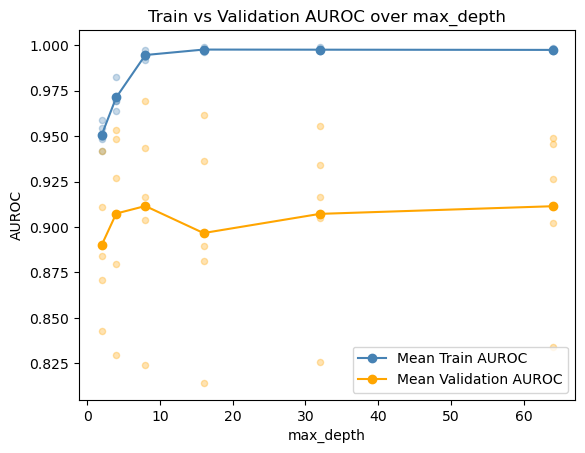

In [38]:
plot_hyperparam_curve(
    results=forest_searcher.cv_results_,
    param_name='param_max_depth',
    fixed_params={
        'param_n_estimators': 100,
        'param_min_samples_leaf': 5,
        'param_max_features': 2
    }
)

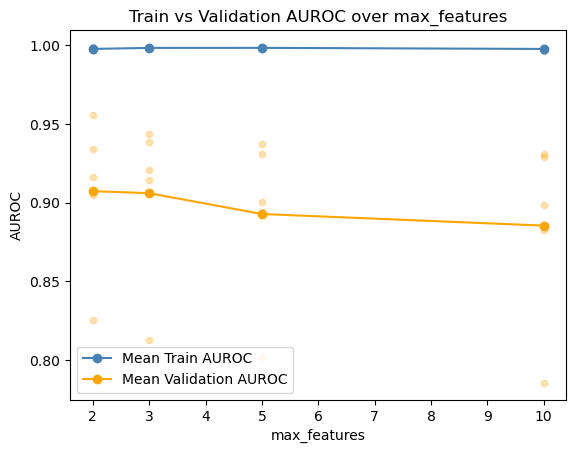

In [39]:
plot_hyperparam_curve(
    results=forest_searcher.cv_results_,
    param_name='param_max_features',
    fixed_params={
        'param_n_estimators': 100,
        'param_min_samples_leaf': 5,
        'param_max_depth': 32
    }
)

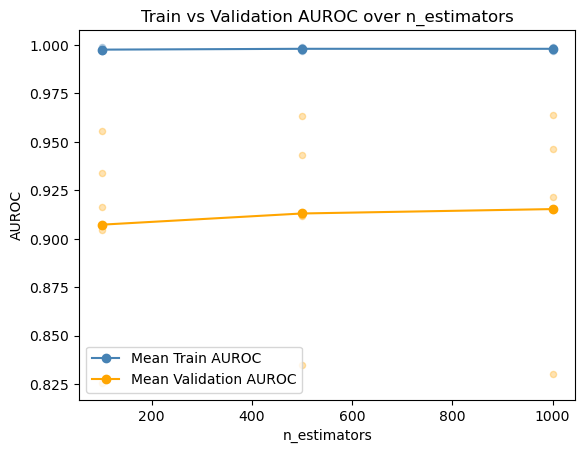

In [40]:
plot_hyperparam_curve(
    results=forest_searcher.cv_results_,
    param_name='param_n_estimators',
    fixed_params={
        'param_max_depth': 32,
        'param_min_samples_leaf': 5,
        'param_max_features': 2
    }
)

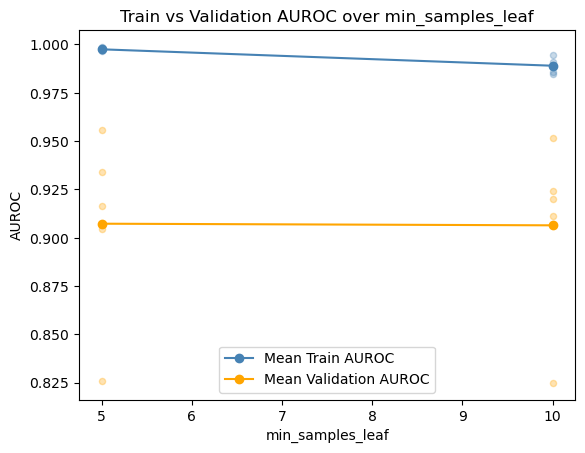

In [41]:
plot_hyperparam_curve(
    results=forest_searcher.cv_results_,
    param_name='param_min_samples_leaf',
    fixed_params={
        'param_n_estimators': 100,
        'param_max_depth': 32,
        'param_max_features': 2
    }
)

In [42]:
# Look at the values in each split
for fold, (train_idx, val_idx) in enumerate(kf.split(x_train, y_train, groups=groups)):
    y_val_fold = y_train.iloc[val_idx]
    pos_pct = y_val_fold.sum() / len(y_val_fold) * 100
    print(f"Fold {fold + 1}: {len(y_val_fold)} samples, {pos_pct:.1f}% positive")

Fold 1: 235 samples, 92.8% positive
Fold 2: 235 samples, 92.3% positive
Fold 3: 235 samples, 92.8% positive
Fold 4: 236 samples, 92.4% positive
Fold 5: 237 samples, 92.0% positive


In [44]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


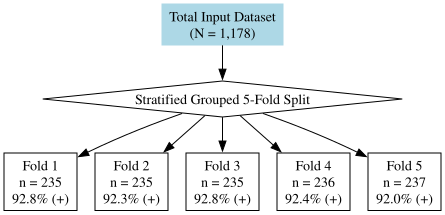

In [47]:
import graphviz

# Create the flowchart
dot = graphviz.Digraph(comment='CV Logistical Summary', format='png')
dot.attr(rankdir='TB', size='8,5')

# Define nodes with specific formatting
dot.node('T', 'Total Input Dataset\n(N = 1,178)', shape='box', style='filled', color='lightblue')
dot.node('S', 'Stratified Grouped 5-Fold Split', shape='diamond')

# Add fold nodes
folds = [
    ("F1", "Fold 1\nn = 235\n92.8% (+)"),
    ("F2", "Fold 2\nn = 235\n92.3% (+)"),
    ("F3", "Fold 3\nn = 235\n92.8% (+)"),
    ("F4", "Fold 4\nn = 236\n92.4% (+)"),
    ("F5", "Fold 5\nn = 237\n92.0% (+)")
]

dot.edge('T', 'S')

for fold_id, label in folds:
    dot.node(fold_id, label, shape='rect')
    dot.edge('S', fold_id)

# Render in the notebook cell
dot